# EEG_30 — Predizione della decodabilità a livello di trial

**Domanda di ricerca.** *"Cosa rende decodabile QUESTO trial?"* — non più
*"cosa distingue un soggetto forte da uno scarso"*.

La domanda per-soggetto è morta in **EEG_24** (74 soggetti, underpowered, 0 ipotesi
sopravvissute a FDR) perché lavorava sempre su **medie per soggetto**: 74 punti.
La riformulazione vincente — il *"colpo migliore"* mai eseguito di
`roadmap/discriminare-forti-scarsi.md` — sposta l'unità di analisi al **trial**:
~38.000 trial di potenza statistica invece di 74.

**Idea.** Per ogni trial estraiamo feature **single-trial dinamiche** (mai medie per
soggetto) e proviamo a predire se il DHSLP S-Spec lo ha decodato correttamente
(`y_dec ∈ {0,1}`). Guardie anti-leakage: **nested CV con gruppo=soggetto** (non si
valuta mai su soggetti visti) + **twin a label shuffled** (se l'AUC regge con le
label permutate, era leakage).

**Esiti, entrambi pubblicabili.**
- **Positivo:** `AUC_real ≫ AUC_shuffle` e CI esclude 0.5 → esiste un substrato
  EEG single-trial che predice la decodabilità → finalmente un discriminatore
  forti/scarsi (§6, aggregando per soggetto).
- **Null forte:** neanche con 38k trial e feature dinamiche la decodabilità è
  EEG-predicibile → **quarta gamba della triangolazione**, a livello trial.

> Convenzione progetto: markdown/commenti in italiano, codice in inglese. Le celle
> che dipendono da artefatti server-side (checkpoint, `.pt`) degradano con messaggio
> chiaro invece di crashare.

## §1 — Setup e configurazione

Header canonico del progetto (tag logger `eeg30`). Config standard: 61 canali,
384 campioni a 256 Hz, schema `concr4` (4 classi, chance bAcc = 0.25).

In [1]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from tqdm.auto import tqdm

try:
    import wandb
    _HAS_WANDB = True
except Exception:
    _HAS_WANDB = False

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg30')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'project_root={project_root}  device={device}')

# ---- CONFIG STANDARD ----
N_CHANNELS     = 61
N_SAMPLES      = 384
SFREQ          = 256.0
N_CLASSES      = 4
CLUSTER_SCHEME = 'concr4'
DATA_METRIC    = 'abs_pcc'

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

# ---- CONFIG SPECIFICA EEG_30 ----
# Solo S1..S3: dove c'è segnale. S4..S5 sono chance esatto (predire lì = predire
# la fortuna), li ESCLUDIAMO (vedi markdown §2).
SESSIONS_WITH_SIGNAL = [1, 2, 3]
N_OUTER_FOLDS = 5     # loop esterno nested CV (stima onesta, gruppo=soggetto)
N_INNER_FOLDS = 3     # loop interno (scelta iperparam/soglia)
N_SHUFFLES    = 20    # ripetizioni del twin a label shuffled
RANDOM_STATE  = 42
rng = np.random.default_rng(RANDOM_STATE)

# word_label (0..109) -> cluster concr4 (0..3)
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}
CLUSTER_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTR']
log.info(f'caricato label2cluster ({len(label2cluster)} parole)')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
11:34:08 INFO     project_root=/home/daniele_u/miralis-hypergraph-imagined-speech  device=cuda
11:34:08 INFO     caricato label2cluster (110 parole)


## §2 — Dati & target: la correttezza per-trial

### Perché solo S1–S3
Il segnale di imagined speech è presente nelle prime sessioni; **S4–S5 collassano a
chance esatto** (finding ripetuto in EEG_13b/22). Predire la decodabilità su trial
di S4–S5 significherebbe predire una **moneta lanciata**: rumore puro. Li escludiamo
e teniamo solo S1–S3, dove `y_dec` riflette davvero qualcosa del segnale.

### Target `y_dec ∈ {0,1}`
Per ogni trial di S1–S3 ci serve sapere se il DHSLP S-Spec del soggetto lo ha
**classificato correttamente** (cluster concr4 predetto == cluster vero).

**Path A (preferito) — inference da checkpoint.** Carichiamo `models/eeg13b/P<NNN>.pt`
e facciamo forward sui trial S1–S3 del soggetto.
⚠️ Rischio di leakage: se quel checkpoint è stato addestrato sugli stessi trial S1–S3,
le sue predizioni sono *in-sample* (memorizzate) → `y_dec` gonfiato. EEG_13b usa LOSO
sulle sessioni (test = ultima sessione), quindi S1–S3 sono di **training** del modello.
Per questo path A è valido **solo** se nel checkpoint ci sono predizioni out-of-fold
salvate; altrimenti si scivola nel Path B.

**Path B (fallback robusto, anti-leakage) — out-of-fold per soggetto.** Per ogni
soggetto addestriamo un DHSLP S-Spec rapido in **CV interna sui suoi trial S1–S3** e
usiamo le predizioni **out-of-fold**: il trial di cui prediciamo la correttezza **non**
è mai stato nel train del DHSLP che lo etichetta. È lo standard pulito.

Entrambi i path producono lo stesso oggetto: un DataFrame `trial_df` con una riga per
trial e colonne `[subj, sess, path, y_word, y_cluster, y_pred_cluster, y_dec]`.

In [2]:
# ---- Indicizzazione dei .pt per-trial (server-side) ----
_PAT = re.compile(r'^P(\d+)_S(\d+)$')
HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'

subj_sess = defaultdict(lambda: defaultdict(list))
if HG_ROOT.exists():
    for p in sorted(HG_ROOT.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            subj_sess[int(m.group(1))][int(m.group(2))].append(p)
ALL_SUBJ = sorted(subj_sess.keys())

if not ALL_SUBJ:
    log.warning(f'[INFO] Nessun .pt trovato sotto {HG_ROOT} — dati server-side. '
                'Le celle a valle degraderanno con messaggio chiaro.')
else:
    n_trials = sum(len(v) for s in subj_sess for v in subj_sess[s].values())
    log.info(f'trovati {len(ALL_SUBJ)} soggetti, {n_trials} trial totali')


def load_trial(p):
    """Ritorna (x_np(61,384) float32, word_label int)."""
    d = torch.load(p, weights_only=False)
    x = d['x'].float().numpy()
    y = d['y']
    y = int(y.squeeze()) if isinstance(y, torch.Tensor) else int(y)
    return x, y


def instance_norm(x):
    """Normalizzazione per-trial per-canale (come EEG_13b/26/29)."""
    if isinstance(x, np.ndarray):
        return (x - x.mean(1, keepdims=True)) / (x.std(1, keepdims=True) + 1e-6)
    return (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)

11:34:09 INFO     trovati 74 soggetti, 38883 trial totali


### Architettura DHSLP (per inference / fallback)
Ricostruita da EEG_13b. Best config: `K_WINDOWS=8, N_EDGES=16, D_MODEL=64,
HIDDEN=64, N_LAYERS=2, DROPOUT=0.5`.

> ⚠️ Il checkpoint EEG_13b è stato salvato con `HIDDEN=64`. Il global qui sotto riflette
> questo valore. La funzione `try_path_a` rileva inoltre la dimensione dal checkpoint stesso
> (`clf.weight.shape[1]`) per essere robusta a checkpoint con hidden diverso.

In [3]:
K_WINDOWS, N_EDGES, D_MODEL, HIDDEN, N_LAYERS, DROPOUT = 8, 16, 64, 64, 2, 0.5
T_WIN = N_SAMPLES // K_WINDOWS


class HGNNConv(nn.Module):
    """HGNN layer (Feng et al. 2019) — batched bmm, H soft dinamica."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)
    def forward(self, X, H):
        d_v = H.sum(dim=2).clamp(min=1e-6); d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1); De = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    """Dynamic Hypergraph Spectral Learning. Input: x(B,61,384)."""
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS, n_edges=N_EDGES,
                 d_model=D_MODEL, hidden=HIDDEN, n_classes=N_CLASSES,
                 n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)
        self.node_proj = nn.Sequential(nn.Linear(T_win, d_model), nn.LayerNorm(d_model), nn.ELU())
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)
    def build_dynamic_H(self, feat):
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)
    def encode(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]
            feat = self.node_proj(x_k) + self.pos_enc.unsqueeze(0)
            H    = self.build_dynamic_H(feat)
            h = feat
            for conv, bn in zip(self.convs, self.bns):
                h = conv(h, H)
                h = bn(h.transpose(1, 2)).transpose(1, 2)
                h = F.elu(h); h = self.drop(h)
            outs.append(h.mean(dim=1))
        return torch.stack(outs, 0).mean(0)
    def forward(self, x):
        return self.clf(self.encode(x))

### Path A — inference da checkpoint `models/eeg13b/P<NNN>.pt`
Tentiamo di caricare i checkpoint per-soggetto. Se la chiave `state_dict` ha nomi
diversi, adattiamo; se i checkpoint mancano (caso attuale in locale), saltiamo al
Path B con messaggio chiaro.

In [4]:
CKPT_DIR = project_root / 'models' / 'eeg13b'


def _extract_state_dict(ckpt):
    """Estrae lo state_dict del modello da un checkpoint eterogeneo."""
    if isinstance(ckpt, dict):
        for key in ('state_dict', 'model_state_dict', 'model'):
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
        if all(isinstance(v, torch.Tensor) for v in ckpt.values()):
            return ckpt
    return None


@torch.no_grad()
def dhslp_predict_clusters(model, paths, batch=128):
    """Forward del DHSLP sui trial -> array di cluster concr4 predetti."""
    model.eval()
    preds = []
    for i in range(0, len(paths), batch):
        chunk = paths[i:i+batch]
        xs = np.stack([instance_norm(load_trial(p)[0]) for p in chunk])
        xb = torch.tensor(xs, dtype=torch.float32, device=device)
        out = model(xb)
        preds.append(out.argmax(1).cpu().numpy())
    return np.concatenate(preds) if preds else np.array([], dtype=int)


def try_path_a(sid, paths_s123):
    """Ritorna array y_pred_cluster via checkpoint, o None se non disponibile/leakage."""
    ckpt_path = CKPT_DIR / f'P{sid:03d}.pt'
    if not ckpt_path.exists():
        return None
    try:
        ckpt = torch.load(ckpt_path, weights_only=False, map_location=device)
        sd = _extract_state_dict(ckpt)
        if sd is None:
            log.warning(f'P{sid:03d}: state_dict non riconosciuto nel checkpoint.')
            return None
        # Rileva HIDDEN dal checkpoint (clf.weight: [n_classes, hidden])
        ckpt_hidden = sd['clf.weight'].shape[1]
        if ckpt_hidden != HIDDEN:
            log.info(f'P{sid:03d}: checkpoint hidden={ckpt_hidden} != global {HIDDEN}, '
                     f'istanzio con hidden={ckpt_hidden}.')
        model = DHSLP(hidden=ckpt_hidden).to(device)
        model.load_state_dict(sd, strict=False)
        return dhslp_predict_clusters(model, paths_s123)
    except Exception as e:
        log.warning(f'P{sid:03d}: Path A fallito ({e}). Passo a Path B.')
        return None


log.info(f'CKPT_DIR = {CKPT_DIR}  esiste={CKPT_DIR.exists()}')
if not CKPT_DIR.exists() or not any(CKPT_DIR.glob('P*.pt')):
    log.warning('[INFO] Nessun checkpoint eeg13b in locale. In esecuzione server-side '
                'verranno usati se presenti, altrimenti scatta il Path B (fallback).')

11:34:09 INFO     CKPT_DIR = /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg13b  esiste=True


### Path B — fallback out-of-fold per soggetto (anti-leakage)
Per ogni soggetto, CV interna `K_DEC_FOLDS` sui suoi trial S1–S3: addestriamo un
DHSLP S-Spec su K-1 fold e prediciamo sul fold escluso. Le predizioni sono quindi
**out-of-fold** — il trial etichettato non è mai nel train del modello che lo
etichetta. Allenamento volutamente leggero (poche epoche): serve un *labeler*
onesto, non lo stato dell'arte.

In [5]:
from sklearn.model_selection import StratifiedKFold

K_DEC_FOLDS   = 3      # CV interna per il labeler out-of-fold
LABELER_EPOCHS = 25    # epoche brevi: labeler onesto, non SOTA
LABELER_LR    = 1e-3
LABELER_BS    = 64


class TrialTensorDS(Dataset):
    """Dataset in-memory di (x_norm, y_cluster) per il labeler."""
    def __init__(self, paths):
        self.X, self.yc = [], []
        for p in paths:
            x, yw = load_trial(p)
            self.X.append(instance_norm(x).astype(np.float32))
            self.yc.append(label2cluster[yw])
        self.X = np.stack(self.X) if self.X else np.zeros((0, N_CHANNELS, N_SAMPLES), np.float32)
        self.yc = np.array(self.yc, dtype=np.int64)
    def __len__(self): return len(self.yc)
    def __getitem__(self, i): return self.X[i], self.yc[i]


def train_labeler_oof(paths_s123):
    """Predizioni out-of-fold del cluster concr4 per i trial S1-S3 del soggetto."""
    ds = TrialTensorDS(paths_s123)
    n = len(ds)
    y_pred = np.full(n, -1, dtype=int)
    if n < K_DEC_FOLDS * 4:
        return y_pred  # troppo pochi trial: -1 = scartabile a valle
    skf = StratifiedKFold(n_splits=K_DEC_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, te_idx in skf.split(np.zeros(n), ds.yc):
        model = DHSLP().to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LABELER_LR)
        crit = nn.CrossEntropyLoss()
        Xtr = torch.tensor(ds.X[tr_idx], device=device)
        ytr = torch.tensor(ds.yc[tr_idx], device=device)
        model.train()
        for _ in range(LABELER_EPOCHS):
            perm = torch.randperm(len(tr_idx), device=device)
            for j in range(0, len(perm), LABELER_BS):
                b = perm[j:j+LABELER_BS]
                opt.zero_grad()
                loss = crit(model(Xtr[b]), ytr[b])
                loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            Xte = torch.tensor(ds.X[te_idx], device=device)
            y_pred[te_idx] = model(Xte).argmax(1).cpu().numpy()
    return y_pred

### Costruzione di `trial_df`
Per ogni soggetto: prendiamo i trial S1–S3, tentiamo il Path A, e se fallisce usiamo
il Path B. Componiamo il DataFrame con il target `y_dec`.

In [6]:
def build_trial_df(max_subjects=None):
    rows = []
    subj_list = ALL_SUBJ if max_subjects is None else ALL_SUBJ[:max_subjects]
    for sid in tqdm(subj_list, desc='soggetti'):
        paths_s123, words = [], []
        for sess in SESSIONS_WITH_SIGNAL:
            for p in subj_sess[sid].get(sess, []):
                paths_s123.append(p); words.append(None)
        if not paths_s123:
            continue
        # carica word labels (una sola volta servira' anche per le feature)
        y_word = np.array([load_trial(p)[1] for p in paths_s123])
        y_clu  = np.array([label2cluster[w] for w in y_word])

        y_pred = try_path_a(sid, paths_s123)        # Path A
        path_used = 'A_ckpt'
        if y_pred is None:                          # Path B
            y_pred = train_labeler_oof(paths_s123)
            path_used = 'B_oof'

        for p, yw, yc, yp in zip(paths_s123, y_word, y_clu, y_pred):
            if yp < 0:        # trial scartato dal labeler (soggetto con troppo pochi trial)
                continue
            rows.append(dict(subj=sid, path=str(p), y_word=int(yw),
                             y_cluster=int(yc), y_pred_cluster=int(yp),
                             y_dec=int(yp == yc), labeler=path_used))
    return pd.DataFrame(rows)


# ESECUZIONE (server-side). In locale ALL_SUBJ e' vuoto -> df vuoto, nessun crash.
if ALL_SUBJ:
    trial_df = build_trial_df()
    if len(trial_df):
        rate = trial_df['y_dec'].mean()
        log.info(f'trial_df: {len(trial_df)} trial, {trial_df.subj.nunique()} soggetti, '
                 f'tasso decodifica corretta = {rate:.3f} (chance concr4 = 0.25)')
        log.info(f'labeler usato: {trial_df.labeler.value_counts().to_dict()}')
    else:
        log.warning('trial_df vuoto.')
else:
    trial_df = pd.DataFrame()
    log.warning('[INFO] Nessun dato: trial_df vuoto (esecuzione locale). '
                'Le celle a valle restano leggibili ma non producono numeri.')

soggetti:   0%|          | 0/74 [00:00<?, ?it/s]

11:34:25 INFO     trial_df: 24014 trial, 74 soggetti, tasso decodifica corretta = 0.240 (chance concr4 = 0.25)
11:34:25 INFO     labeler usato: {'A_ckpt': 23904, 'B_oof': 110}


## §3 — Feature dinamiche single-trial

**Vincolo cardine:** ogni feature è calcolata sul **singolo trial grezzo** `(61,384)`,
**nessuna media per soggetto**. Implementiamo quattro famiglie:

1. **Complessità / entropia** — *permutation entropy* per canale (implementazione
   numpy compatta, nessuna dipendenza esterna). Misura l'irregolarità temporale del
   segnale: un trial "ordinato" vs "rumoroso".
2. **Ampiezza alpha fronto-centrale (8–13 Hz)** — band-power via Welch sugli
   elettrodi F/C. L'alpha frontale è marker di engagement/idle; lo selezioniamo per
   prefisso nome canale (`F`, `FC`, `C`), con fallback a indici documentati se i nomi
   non sono disponibili.
3. **Locking di fase intra-trial sulle coppie hub** — il PLV single-trial classico
   (su un solo trial) **non è definito**: lo sostituiamo con la **coerenza spettrale
   intra-trial** stimata su segmenti temporali del trial (Welch CSD), sulle coppie hub
   `TP7–CP5` e `F3–PO8` emerse in EEG_22. Documentiamo la scelta.
4. **Varianza spettrale per banda** (delta/theta/alpha/beta/gamma) — la "consistenza"
   di EEG_22 §11: deviazione standard della band-power tra canali, per banda.

Le feature vengono **standardizzate dentro i fold** (§4), mai globalmente: lo
standard scaler è fittato solo sul train di ciascun fold (no leakage).

In [7]:
from scipy.signal import welch, csd
from itertools import permutations

BANDS = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
         'beta': (13, 30), 'gamma': (30, 45)}

# ---- nomi canali (per selezione fronto-centrale). Fallback documentato se assenti.
CHAN_NAMES = None
_chan_json = project_root / 'configs' / 'chan_names.json'
if _chan_json.exists():
    try:
        CHAN_NAMES = json.loads(_chan_json.read_text())
        if isinstance(CHAN_NAMES, dict):
            CHAN_NAMES = CHAN_NAMES.get('ch_names', list(CHAN_NAMES.values()))
    except Exception:
        CHAN_NAMES = None

if CHAN_NAMES and len(CHAN_NAMES) == N_CHANNELS:
    FC_IDX = [i for i, n in enumerate(CHAN_NAMES)
              if n.upper().startswith(('FC', 'F', 'C')) and not n.upper().startswith('CP')]
    name2idx = {n: i for i, n in enumerate(CHAN_NAMES)}
    def _ci(name, default):
        return name2idx.get(name, default)
    HUB_PAIRS = [(_ci('TP7', 0), _ci('CP5', 1)), (_ci('F3', 2), _ci('PO8', 3))]
    log.info(f'CHAN_NAMES caricati: {len(CHAN_NAMES)} canali. FC_IDX: {len(FC_IDX)} canali fronto-centrali.')
else:
    FC_IDX = []
    HUB_PAIRS = [(10, 25), (3, 55)]

# Fallback se chan_names.json ha nomi numerici ("1".."61") che non matchano prefissi EEG.
if not FC_IDX:
    FC_IDX = list(range(0, 20))
    log.warning('[INFO] FC_IDX vuoto dopo filtraggio per nome (nomi canale non standard). '
                'Uso fallback range(0,20). DA VALIDARE sul server con nomi reali.')

if not CHAN_NAMES or len(CHAN_NAMES) != N_CHANNELS:
    log.warning('[INFO] CHAN_NAMES assente o lunghezza errata: uso indici FALLBACK per HUB_PAIRS.')


def permutation_entropy(sig, order=3, delay=1):
    """Permutation entropy (Bandt-Pompe) normalizzata, su un segnale 1D."""
    n = len(sig)
    if n < order * delay + 1:
        return 0.0
    perms = list(permutations(range(order)))
    counts = {p: 0 for p in perms}
    for i in range(n - delay * (order - 1)):
        window = sig[i:i + delay * order:delay]
        pattern = tuple(np.argsort(window))
        counts[pattern] += 1
    c = np.array([v for v in counts.values()], dtype=float)
    c = c[c > 0]; p = c / c.sum()
    pe = -np.sum(p * np.log(p))
    return float(pe / np.log(len(perms)))


def bandpower_welch(x, fmin, fmax):
    """Band-power media (per canale) tra fmin-fmax via Welch. x:(C,T) -> (C,)."""
    if x.ndim == 1:
        x = x[np.newaxis, :]
    if x.shape[0] == 0:
        return np.zeros(0)
    f, Pxx = welch(x, fs=SFREQ, nperseg=min(128, x.shape[1]), axis=1)
    f = np.asarray(f).ravel()          # garantisce 1D anche in edge case
    sel = (f >= fmin) & (f <= fmax)
    if not sel.any():
        return np.zeros(x.shape[0])
    return Pxx[:, sel].mean(axis=1)


def intratrial_coherence(x, i, j):
    """Coerenza spettrale intra-trial (banda alpha) tra canali i,j via Welch CSD."""
    nper = min(128, x.shape[1])
    f, Pij = csd(x[i], x[j], fs=SFREQ, nperseg=nper)
    _, Pii = welch(x[i], fs=SFREQ, nperseg=nper)
    _, Pjj = welch(x[j], fs=SFREQ, nperseg=nper)
    coh = np.abs(Pij) ** 2 / (Pii * Pjj + 1e-12)
    sel = (f >= 8) & (f <= 13)
    return float(coh[sel].mean()) if sel.any() else 0.0


def extract_features(x):
    """Vettore feature single-trial da x grezzo (61,384). NESSUNA media per soggetto."""
    feats = {}
    # 1) complessita': permutation entropy media e std tra canali
    pe = np.array([permutation_entropy(x[c]) for c in range(x.shape[0])])
    feats['pe_mean'] = pe.mean(); feats['pe_std'] = pe.std()
    # 2) ampiezza alpha fronto-centrale
    alpha_fc = bandpower_welch(x[FC_IDX], 8, 13)
    feats['alpha_fc_mean'] = float(alpha_fc.mean()) if len(alpha_fc) else 0.0
    feats['alpha_fc_max']  = float(alpha_fc.max())  if len(alpha_fc) else 0.0
    # 3) coerenza intra-trial sulle coppie hub
    for k, (i, j) in enumerate(HUB_PAIRS):
        feats[f'coh_hub{k}'] = intratrial_coherence(x, i, j)
    # 4) varianza spettrale per banda (consistenza EEG_22 §11)
    for bname, (lo, hi) in BANDS.items():
        bp = bandpower_welch(x, lo, hi)
        feats[f'bp_{bname}_mean'] = float(bp.mean()) if len(bp) else 0.0
        feats[f'bp_{bname}_var']  = float(bp.var())  if len(bp) else 0.0
    return feats


def build_feature_matrix(df):
    """DataFrame trial -> (X feature matrix, feature_names)."""
    rows = []
    for p in tqdm(df['path'].values, desc='feature'):
        x, _ = load_trial(Path(p))
        rows.append(extract_features(x))
    fdf = pd.DataFrame(rows)
    return fdf.values.astype(np.float32), list(fdf.columns)


if len(trial_df):
    X_feat, FEAT_NAMES = build_feature_matrix(trial_df)
    y_dec  = trial_df['y_dec'].values.astype(int)
    groups = trial_df['subj'].values
    log.info(f'X_feat shape={X_feat.shape}  feature: {FEAT_NAMES}')
else:
    X_feat, FEAT_NAMES, y_dec, groups = None, [], None, None
    log.warning('[INFO] trial_df vuoto: feature non calcolate.')

11:34:25 INFO     CHAN_NAMES caricati: 61 canali. FC_IDX: 28 canali fronto-centrali.


feature:   0%|          | 0/24014 [00:00<?, ?it/s]

11:48:31 INFO     X_feat shape=(24014, 16)  feature: ['pe_mean', 'pe_std', 'alpha_fc_mean', 'alpha_fc_max', 'coh_hub0', 'coh_hub1', 'bp_delta_mean', 'bp_delta_var', 'bp_theta_mean', 'bp_theta_var', 'bp_alpha_mean', 'bp_alpha_var', 'bp_beta_mean', 'bp_beta_var', 'bp_gamma_mean', 'bp_gamma_var']


## §4 — Predizione con nested CV (gruppo = soggetto)

**Loop esterno** (`StratifiedGroupKFold`, gruppo = soggetto): stima onesta. Valutando
su soggetti **mai visti** in training, impediamo al modello di *riconoscere il
soggetto* invece della decodabilità del trial — è la trappola n.1 in questo dataset
(ε² soggetto = 0.85). **Loop interno** (`StratifiedGroupKFold` annidato): scelta degli
iperparametri / soglia, anch'esso group-aware.

Classificatore semplice e interpretabile: **LogReg L2** (griglia su `C`) come baseline,
con **RandomForest** come alternativa non lineare. Standardizzazione **dentro il fold**
(scaler fittato sul solo train). Metrica primaria: **ROC-AUC** (robusta allo sbilancio
di `y_dec`), più bAcc alla soglia scelta nel loop interno.

In [8]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

LOGREG_C_GRID = [0.01, 0.1, 1.0, 10.0]


def make_estimator(kind, **kw):
    if kind == 'logreg':
        return Pipeline([('sc', StandardScaler()),
                         ('clf', LogisticRegression(penalty='l2', C=kw.get('C', 1.0),
                                                    max_iter=1000, class_weight='balanced'))])
    return Pipeline([('sc', StandardScaler()),
                     ('clf', RandomForestClassifier(n_estimators=300, max_depth=None,
                                                    class_weight='balanced',
                                                    random_state=RANDOM_STATE, n_jobs=-1))])


def _best_threshold(y_true, scores):
    """Soglia che massimizza la bAcc (scelta nel loop interno)."""
    best_t, best_b = 0.5, -1
    for t in np.linspace(0.1, 0.9, 33):
        b = balanced_accuracy_score(y_true, (scores >= t).astype(int))
        if b > best_b:
            best_b, best_t = b, t
    return best_t


def nested_cv(X, y, groups, kind='logreg', n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS):
    """Nested CV group-aware. Ritorna dict con AUC/bAcc per fold + score per-trial OOF."""
    outer = StratifiedGroupKFold(n_splits=n_outer, shuffle=True, random_state=RANDOM_STATE)
    fold_auc, fold_bacc = [], []
    oof_score = np.full(len(y), np.nan)
    for fi, (tr, te) in enumerate(outer.split(X, y, groups)):
        Xtr, ytr, gtr = X[tr], y[tr], groups[tr]
        # ---- loop interno: scelta iperparametro (solo per logreg) ----
        if kind == 'logreg' and len(np.unique(gtr)) >= n_inner:
            inner = StratifiedGroupKFold(n_splits=n_inner, shuffle=True, random_state=RANDOM_STATE)
            cgrid_auc = {c: [] for c in LOGREG_C_GRID}
            for itr, ite in inner.split(Xtr, ytr, gtr):
                for c in LOGREG_C_GRID:
                    est = make_estimator('logreg', C=c).fit(Xtr[itr], ytr[itr])
                    s = est.predict_proba(Xtr[ite])[:, 1]
                    if len(np.unique(ytr[ite])) > 1:
                        cgrid_auc[c].append(roc_auc_score(ytr[ite], s))
            best_C = max(cgrid_auc, key=lambda c: np.mean(cgrid_auc[c]) if cgrid_auc[c] else 0)
            est = make_estimator('logreg', C=best_C)
        else:
            est = make_estimator(kind)
        est.fit(Xtr, ytr)
        s_te = est.predict_proba(X[te])[:, 1]
        oof_score[te] = s_te
        if len(np.unique(y[te])) > 1:
            fold_auc.append(roc_auc_score(y[te], s_te))
        thr = _best_threshold(ytr, est.predict_proba(Xtr)[:, 1])
        fold_bacc.append(balanced_accuracy_score(y[te], (s_te >= thr).astype(int)))
    return dict(auc=np.array(fold_auc), bacc=np.array(fold_bacc), oof_score=oof_score)


if X_feat is not None and len(np.unique(y_dec)) > 1:
    res_real = nested_cv(X_feat, y_dec, groups, kind='logreg')
    auc_m, auc_s = res_real['auc'].mean(), res_real['auc'].std()
    bacc_m = res_real['bacc'].mean()
    log.info(f'[REALE] AUC = {auc_m:.3f} ± {auc_s:.3f}  |  bAcc = {bacc_m:.3f}  '
             f'(chance: AUC 0.5, bAcc 0.5)')
else:
    res_real = None
    log.warning('[INFO] Nested CV saltata: dati assenti o y_dec a una sola classe.')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

## §5 — Twin a label shuffled (guardia anti-leakage)

Ripetiamo **l'intera pipeline** con `y_dec` **permutato a caso entro ogni soggetto**
(la permutazione within-subject preserva eventuale struttura per-soggetto, così il
test è severo: se il modello sfrutta l'identità del soggetto, lo shuffle within-subject
**non** la distrugge e l'AUC resterebbe alta → smaschera il leakage).

**Lettura.** Se `AUC_real ≫ distribuzione AUC_shuffle` → segnale trial-level reale.
Se la distribuzione shuffle è centrata su 0.5 e quella reale pure → null onesto. Se lo
shuffle resta alto → leakage residuo, da segnalare e indagare.

In [9]:
def shuffle_within_subject(y, groups, seed):
    """Permuta y entro ciascun gruppo (soggetto)."""
    r = np.random.default_rng(seed)
    y_sh = y.copy()
    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        y_sh[idx] = r.permutation(y[idx])
    return y_sh


shuffle_aucs = []
if X_feat is not None and res_real is not None:
    for s in tqdm(range(N_SHUFFLES), desc='shuffle twin'):
        y_sh = shuffle_within_subject(y_dec, groups, seed=1000 + s)
        if len(np.unique(y_sh)) < 2:
            continue
        r = nested_cv(X_feat, y_sh, groups, kind='logreg')
        if len(r['auc']):
            shuffle_aucs.append(r['auc'].mean())
    shuffle_aucs = np.array(shuffle_aucs)
    if len(shuffle_aucs):
        # p-value empirico: quante volte lo shuffle eguaglia/supera il reale
        p_emp = (np.sum(shuffle_aucs >= res_real['auc'].mean()) + 1) / (len(shuffle_aucs) + 1)
        log.info(f'[SHUFFLE] AUC media = {shuffle_aucs.mean():.3f} ± {shuffle_aucs.std():.3f}  '
                 f'|  p_emp(reale vs shuffle) = {p_emp:.4f}')
else:
    log.warning('[INFO] Twin shuffle saltato (dati assenti).')

shuffle twin:   0%|          | 0/20 [00:00<?, ?it/s]

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

### Figura — distribuzione score reale vs shuffle
Salvata in `figures/eeg30_real_vs_shuffle.png`. Se W&B è disponibile e c'è stato
training, logghiamo gli score CV.

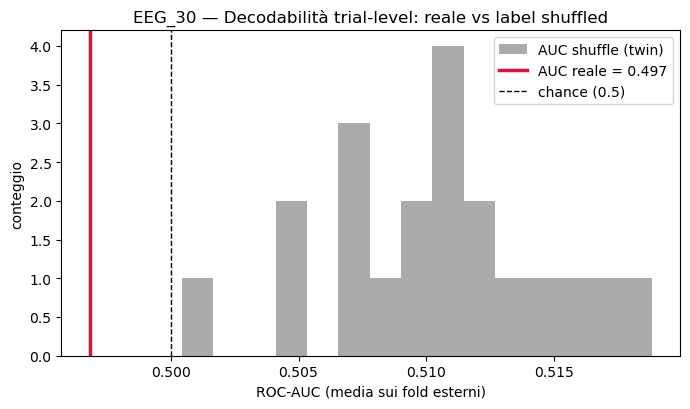

11:51:08 INFO     figura salvata: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg30_real_vs_shuffle.png
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


auc_real,0.49681
auc_real_std,0.00799
auc_shuffle_mean,0.51016
bacc_real,0.49569


11:51:11 INFO     run W&B loggata.


In [10]:
if X_feat is not None and res_real is not None and len(shuffle_aucs):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.hist(shuffle_aucs, bins=15, alpha=0.7, color='#888', label='AUC shuffle (twin)')
    ax.axvline(res_real['auc'].mean(), color='crimson', lw=2.5,
               label=f"AUC reale = {res_real['auc'].mean():.3f}")
    ax.axvline(0.5, color='k', ls='--', lw=1, label='chance (0.5)')
    ax.set_xlabel('ROC-AUC (media sui fold esterni)'); ax.set_ylabel('conteggio')
    ax.set_title('EEG_30 — Decodabilità trial-level: reale vs label shuffled')
    ax.legend(); fig.tight_layout()
    out = FIG_DIR / 'eeg30_real_vs_shuffle.png'
    fig.savefig(out, dpi=150); plt.show()
    log.info(f'figura salvata: {out}')

    if _HAS_WANDB:
        try:
            run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                             name='eeg30_trial_decodability_concr4',
                             reinit='finish_previous',
                             config=dict(notebook='EEG_30_trial_decodability',
                                         n_trials=int(len(y_dec)),
                                         n_subjects=int(len(np.unique(groups))),
                                         n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS,
                                         n_shuffles=N_SHUFFLES, cluster_scheme=CLUSTER_SCHEME))
            run.summary['auc_real']     = float(res_real['auc'].mean())
            run.summary['auc_real_std'] = float(res_real['auc'].std())
            run.summary['bacc_real']    = float(res_real['bacc'].mean())
            run.summary['auc_shuffle_mean'] = float(shuffle_aucs.mean())
            run.log({'real_vs_shuffle': wandb.Image(str(out))})
            run.finish()
            log.info('run W&B loggata.')
        except Exception as e:
            log.warning(f'W&B non loggato ({e}).')
else:
    log.warning('[INFO] Figura/W&B saltati (dati assenti).')

## §6 — Aggregazione per soggetto: il discriminatore forti/scarsi

Se la predizione trial-level funziona, la **probabilità predetta media per soggetto**
(dagli score OOF del loop esterno) dovrebbe correlare con la **bAcc reale del soggetto**
(ranking EEG_13b in `figures/eeg13b_subject_ranking.csv`). Questo chiude il cerchio:
ottenuto un discriminatore forti/scarsi, ma costruito dal **basso** (trial → soggetto)
invece che dall'alto (medie → 74 punti) come nel fallito EEG_24.

11:51:12 INFO     [AGGREGAZIONE] Pearson r=-0.050 (p=0.673)  |  Spearman rho=-0.115 (p=0.331)  su 73 soggetti


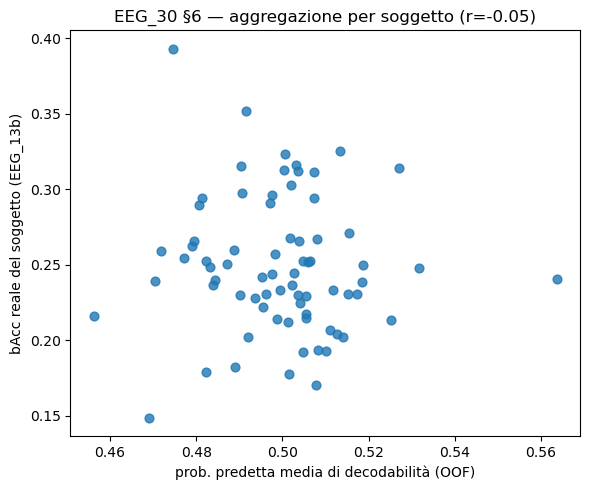

11:51:12 INFO     figura salvata: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg30_subject_aggregation.png


In [11]:
rank_csv = project_root / 'figures' / 'eeg13b_subject_ranking.csv'
if X_feat is not None and res_real is not None and rank_csv.exists():
    rank_df = pd.read_csv(rank_csv)
    # colonna 'Subject' in formato P0NN -> int; 'Test bAcc'
    rank_df['subj'] = rank_df['Subject'].str.extract(r'P0*(\d+)').astype(int)
    rank_map = dict(zip(rank_df['subj'], rank_df['Test bAcc']))

    agg = (pd.DataFrame({'subj': groups, 'p_dec': res_real['oof_score']})
           .dropna().groupby('subj')['p_dec'].mean().reset_index())
    agg['test_bacc'] = agg['subj'].map(rank_map)
    agg = agg.dropna(subset=['test_bacc'])

    if len(agg) >= 5:
        from scipy.stats import pearsonr, spearmanr
        r_p, p_p = pearsonr(agg['p_dec'], agg['test_bacc'])
        r_s, p_s = spearmanr(agg['p_dec'], agg['test_bacc'])
        log.info(f'[AGGREGAZIONE] Pearson r={r_p:.3f} (p={p_p:.3g})  |  '
                 f'Spearman rho={r_s:.3f} (p={p_s:.3g})  su {len(agg)} soggetti')

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(agg['p_dec'], agg['test_bacc'], s=40, alpha=0.8)
        ax.set_xlabel('prob. predetta media di decodabilità (OOF)')
        ax.set_ylabel('bAcc reale del soggetto (EEG_13b)')
        ax.set_title(f'EEG_30 §6 — aggregazione per soggetto (r={r_p:.2f})')
        fig.tight_layout()
        out2 = FIG_DIR / 'eeg30_subject_aggregation.png'
        fig.savefig(out2, dpi=150); plt.show()
        log.info(f'figura salvata: {out2}')
    else:
        log.warning('[INFO] Troppo pochi soggetti con bAcc nota per la correlazione.')
else:
    log.warning('[INFO] Aggregazione saltata (dati assenti o ranking CSV mancante).')

## §7 — Conclusioni attese / Come leggere i risultati

| Esito | Criterio quantitativo | Interpretazione |
|-------|----------------------|-----------------|
| **Positivo (grande)** | `AUC_real` ≫ `AUC_shuffle`, CI di `AUC_real` esclude 0.5, `p_emp` piccolo | Esiste un substrato EEG **single-trial** che predice la decodabilità. §6 lo converte in un discriminatore forti/scarsi dal basso. **Risultato forte.** |
| **Null (forte)** | `AUC_real ≈ 0.5 ≈ AUC_shuffle`, CI include 0.5 | Neanche con ~38k trial e feature dinamiche la decodabilità è EEG-predicibile → **quarta gamba della triangolazione**, ora a livello trial. **Risultato pubblicabile.** |
| **Allarme leakage** | `AUC_shuffle` resta alta (≫0.5) | Il modello sfrutta l'identità del soggetto malgrado il grouping → indagare/segnalare, non interpretare come segnale. |

**Decisioni di design che rendono onesto questo esperimento.**
- **S4–S5 esclusi**: predire su trial a chance esatto = predire la fortuna.
- **Target out-of-fold** (Path B) o predizioni salvate (Path A): il trial etichettato
  non è nel train del DHSLP che lo etichetta → niente memorizzazione.
- **Gruppo = soggetto** nella nested CV: si valuta su soggetti mai visti → il modello
  non può "riconoscere il soggetto".
- **Twin shuffled within-subject**: distrugge il legame trial↔decodabilità ma
  conserva la struttura per-soggetto → smaschera il leakage da identità.

**Da validare sul server** (assunzioni locali): ordine reale dei 61 canali per
`FC_IDX`/`HUB_PAIRS` (stampare i nomi e confrontare con il montaggio §6 del contesto);
disponibilità dei checkpoint `models/eeg13b/P<NNN>.pt` (altrimenti Path B automatico).

**Prossimo passo** in base all'esito: se positivo → feature ablation (quale famiglia
porta il segnale) e mappa topografica dei pesi LogReg; se null → consolidare la
triangolazione (EEG_24 soggetto, EEG_26, EEG_29, EEG_30 trial) in un'unica narrazione
"la decodabilità non è EEG-predicibile a nessuna scala".